# Expoloratory data analysis (EDA)

In [2]:
import pandas as pd

df = pd.read_csv("salaries.csv")
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2024,SE,FT,AI Engineer,202730,USD,202730,US,0,US,M
1,2024,SE,FT,AI Engineer,92118,USD,92118,US,0,US,M
2,2024,SE,FT,Data Engineer,130500,USD,130500,US,0,US,M
3,2024,SE,FT,Data Engineer,96000,USD,96000,US,0,US,M
4,2024,SE,FT,Machine Learning Engineer,190000,USD,190000,US,0,US,M


In [3]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='str')

# Initial EDA

In [4]:
df.shape

(16534, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16534 entries, 0 to 16533
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   work_year           16534 non-null  int64
 1   experience_level    16534 non-null  str  
 2   employment_type     16534 non-null  str  
 3   job_title           16534 non-null  str  
 4   salary              16534 non-null  int64
 5   salary_currency     16534 non-null  str  
 6   salary_in_usd       16534 non-null  int64
 7   employee_residence  16534 non-null  str  
 8   remote_ratio        16534 non-null  int64
 9   company_location    16534 non-null  str  
 10  company_size        16534 non-null  str  
dtypes: int64(4), str(7)
memory usage: 1.4 MB


In [6]:
pd.__version__ # Kokchun '3.0.1'

'3.0.1'

In [7]:
df["work_year"]

0        2024
1        2024
2        2024
3        2024
4        2024
         ... 
16529    2020
16530    2021
16531    2020
16532    2020
16533    2021
Name: work_year, Length: 16534, dtype: int64

In [8]:
df["company_location"].value_counts()

company_location
US    14518
GB      694
CA      455
ES      133
DE      105
      ...  
DZ        1
IQ        1
CN        1
CL        1
MD        1
Name: count, Length: 77, dtype: int64

change the experience levels to
- SE -> Senior
- MI -> Mid
- EN -> Entry
- EX -> Expert

can we combine salary in USD with job role
- e.g. group by and median for each job role

In [9]:
df["salary_currency"].value_counts().head()

salary_currency
USD    15294
GBP      616
EUR      449
CAD       56
INR       55
Name: count, dtype: int64

In [10]:
df["company_size"].value_counts()

company_size
M    15306
L     1040
S      188
Name: count, dtype: int64

In [11]:
df["job_title"].value_counts().head(10)

job_title
Data Engineer                3464
Data Scientist               3314
Data Analyst                 2440
Machine Learning Engineer    1705
Research Scientist            531
Applied Scientist             435
Data Architect                435
Analytics Engineer            431
Research Engineer             306
Data Science                  271
Name: count, dtype: int64

## Cleaning job titles

In [12]:
import duckdb

duckdb.sql("""--sql
FROM df
WHERE job_title ILIKE 'data%'
""").df()["job_title"].value_counts()

job_title
Data Engineer                    3464
Data Scientist                   3314
Data Analyst                     2440
Data Architect                    435
Data Science                      271
Data Manager                      212
Data Science Manager              122
Data Specialist                    86
Data Science Consultant            83
Data Analytics Manager             62
Data Modeler                       56
Data Product Manager               36
Data Developer                     30
Data Science Engineer              29
Data Lead                          26
Data Science Lead                  26
Data Operations Analyst            24
Data Quality Analyst               24
Data Strategist                    24
Data Integration Specialist        23
Data Analytics Lead                23
Data Management Analyst            22
Data Infrastructure Engineer       22
Data Integration Engineer          20
Data Science Practitioner          16
Data Operations Engineer           16
Da

In [13]:
duckdb.sql("""--sql
FROM df
WHERE job_title ILIKE 'data analy%'
""").df()["job_title"].value_counts()

job_title
Data Analyst                 2440
Data Analytics Manager         62
Data Analytics Lead            23
Data Analytics Specialist       8
Data Analytics Consultant       8
Data Analytics Engineer         5
Data Analyst Lead               2
Data Analytics Associate        1
Name: count, dtype: int64

In [14]:
duckdb.sql("""--sql
FROM df
WHERE job_title ILIKE 'machine learning%engineer%'
""").df()["job_title"].value_counts()

job_title
Machine Learning Engineer                   1705
Machine Learning Infrastructure Engineer      33
Machine Learning Software Engineer            15
Machine Learning Operations Engineer           9
Machine Learning Research Engineer             5
Name: count, dtype: int64

### Clean data

In [15]:
df_cleaned = duckdb.sql("""--sql
SELECT
    * EXCLUDE(job_title, experience_level),
    CASE
        WHEN job_title ILIKE 'data scien%' THEN 'Data Scentist'
        WHEN job_title ILIKE 'data analy%' THEN 'Data Analyst'
        WHEN job_title ILIKE 'machine learning%engineer%' THEN 'Machine Learning Engineer'
        ELSE job_title
    END AS job_title,
    CASE
        WHEN experience_level = 'EN' THEN 'Entry'
        WHEN experience_level = 'MI' THEN 'Mid'
        WHEN experience_level = 'SE' THEN 'Senior'
        WHEN experience_level = 'EX' THEN 'Expert'
        ELSE experience_level
    END AS experience_level
FROM df
""").df()

df_cleaned["job_title"].value_counts().head()

job_title
Data Scentist                3876
Data Engineer                3464
Data Analyst                 2549
Machine Learning Engineer    1767
Research Scientist            531
Name: count, dtype: int64

In [16]:
df_cleaned["experience_level"].value_counts()

experience_level
Senior    10670
Mid        4038
Entry      1325
Expert      501
Name: count, dtype: int64

## Export cleaned  dataset

In [17]:
df_cleaned.to_csv("salaries_cleaned.csv")

# Visualization

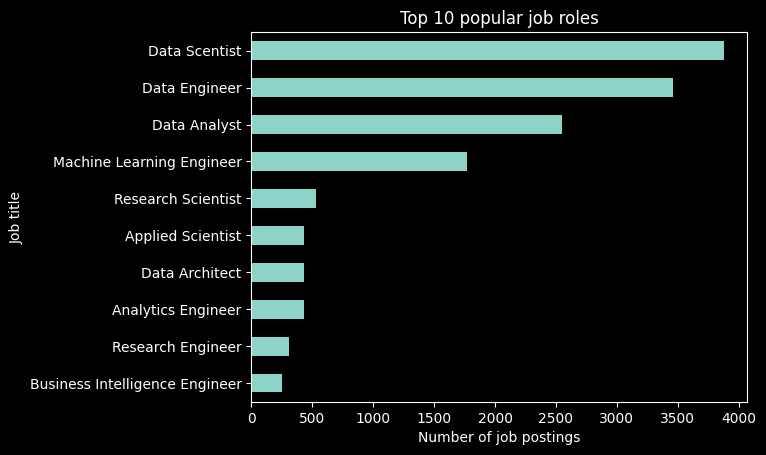

In [18]:
ax = (
    df_cleaned["job_title"]
    .value_counts()
    .head(10)
    .plot(
        kind="barh",
        title="Top 10 popular job roles",
        xlabel="Number of job postings",
        ylabel="Job title",
    )
)
ax.invert_yaxis()

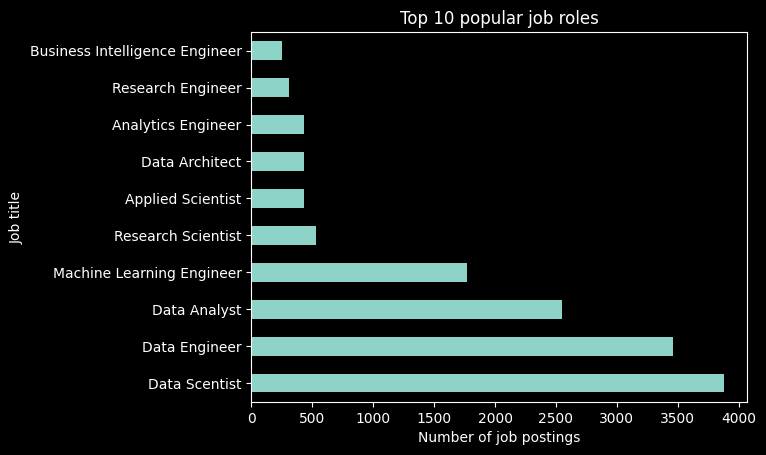

In [19]:
df_cleaned["job_title"].value_counts().head(10).plot(
    kind="barh",
    title="Top 10 popular job roles",
    xlabel="Number of job postings",
    ylabel="Job title",
)

In [20]:
df_cleaned.head()

,work_year,employment_type,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,job_title,experience_level
0,2024,FT,202730,USD,202730,US,0,US,M,AI Engineer,Senior
1,2024,FT,92118,USD,92118,US,0,US,M,AI Engineer,Senior
2,2024,FT,130500,USD,130500,US,0,US,M,Data Engineer,Senior
3,2024,FT,96000,USD,96000,US,0,US,M,Data Engineer,Senior
4,2024,FT,190000,USD,190000,US,0,US,M,Machine Learning Engineer,Senior


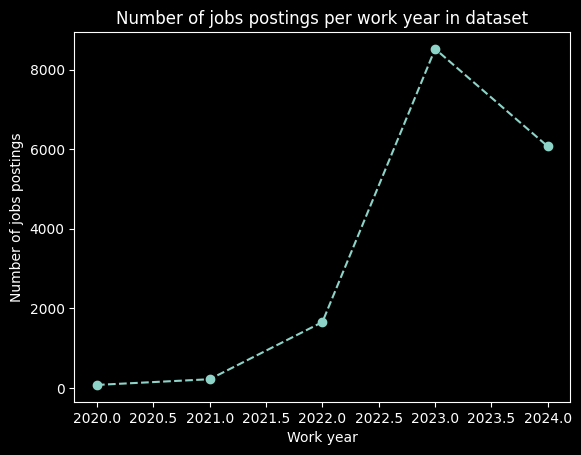

In [23]:
import matplotlib.pyplot as plt
df_cleaned["work_year"].value_counts().sort_index().plot(linestyle="--", marker="o", xlabel="Work year", ylabel="Number of jobs postings", title="Number of jobs postings per work year in dataset",
)

ax.xaxis.set_major_locator(plt.MaxNLocator(int = True))